# Chapter 3: Computational Complexity

This notebook covers the fundamentals of computational complexity analysis:
- **Iteration and Recursion**: two fundamental ways to repeat computation
- **Time Complexity**: how runtime scales with input size
- **Space Complexity**: how memory usage scales with input size

Understanding complexity lets us compare algorithms *independently* of hardware.

In [1]:
import time
import sys
import matplotlib.pyplot as plt
import numpy as np

---
## 1. Iteration and Recursion

Two fundamental strategies for repeating computation:
- **Iteration** (`for`/`while` loops): bottom-up, explicit repetition
- **Recursion** (function calls itself): top-down, breaks problem into sub-problems

### 1.1 For Loop — sum 1 to n

The simplest iteration: sum integers from 1 to n.

In [2]:
def for_loop(n: int) -> int:
    """Iterative sum of 1 + 2 + ... + n  (O(n) time, O(1) space)"""
    res = 0
    for i in range(1, n + 1):
        res += i
    return res

print(for_loop(10))   # Expected: 55
print(for_loop(100))  # Expected: 5050

55
5050


### 1.2 Nested Loops — O(n²)

Each additional loop nesting multiplies the work: n × n = n² pairs.

In [3]:
def nested_for_loop(n: int) -> int:
    """Count all (i, j) pairs with 1 ≤ i, j ≤ n  (O(n²) time)"""
    count = 0
    for i in range(1, n + 1):
        for j in range(1, n + 1):
            count += 1
    return count

print(nested_for_loop(5))   # 25 pairs
print(nested_for_loop(10))  # 100 pairs

25
100


### 1.3 Recursion — sum 1 to n

**Three required components** of every recursive function:
1. **Base case**: stops the recursion
2. **Recursive step**: calls itself with a simpler input
3. **Result combination**: combines sub-results

```
recur(4)
  └─ 4 + recur(3)
         └─ 3 + recur(2)
                └─ 2 + recur(1)
                       └─ 1   ← base case
```

In [4]:
def recur(n: int) -> int:
    """Recursive sum: 1 + 2 + ... + n  (O(n) time, O(n) space due to call stack)"""
    if n == 1:          # base case
        return 1
    return n + recur(n - 1)   # recursive step + combination

print(recur(10))   # 55
print(recur(100))  # 5050

55
5050


### 1.4 Tail Recursion

In **tail recursion** the recursive call is the *last* operation — no pending addition after the call returns. Some languages can optimise this to use O(1) stack space (Python does **not** do this, but the concept is important).

In [5]:
def tail_recur(n: int, res: int = 0) -> int:
    """Tail-recursive sum — accumulator holds running total."""
    if n == 0:
        return res
    return tail_recur(n - 1, res + n)   # all computation BEFORE the call

print(tail_recur(10))   # 55

55


### 1.5 Fibonacci — classic recursion tree

The Fibonacci sequence: 0, 1, 1, 2, 3, 5, 8, …  
f(n) = f(n-1) + f(n-2), with f(1)=0, f(2)=1.

In [6]:
def fib(n: int) -> int:
    """Naive recursive Fibonacci — O(2^n) time!"""
    if n == 1 or n == 2:
        return n - 1      # f(1)=0, f(2)=1
    return fib(n - 1) + fib(n - 2)

print([fib(i) for i in range(1, 11)])  # first 10 Fibonacci numbers

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]


---
## 2. Time Complexity

**Big-O notation** describes how the *number of operations* grows as input size n → ∞.  
We keep only the fastest-growing term and drop constants:

| Expression T(n) | Big-O |
|---|---|
| 100 000 | O(1) |
| 3n + 2 | O(n) |
| 2n² + 3n + 2 | O(n²) |
| n³ + 10 000n² | O(n³) |
| 2ⁿ + 10 000n¹⁰ | O(2ⁿ) |

**Hierarchy (best → worst):**  
O(1) < O(log n) < O(n) < O(n log n) < O(n²) < O(2ⁿ) < O(n!)

### 2.1 Constant Time — O(1)

In [7]:
def constant(n: int) -> None:
    """O(1): always does the same fixed number of operations."""
    size = 1_000_000
    _ = size * 2   # just two operations, regardless of n

# Let's time it for different n values
for n in [10, 1000, 1_000_000]:
    t0 = time.perf_counter()
    constant(n)
    elapsed = time.perf_counter() - t0
    print(f"n={n:>10}: {elapsed:.2e}s")

n=        10: 4.58e-07s
n=      1000: 7.08e-07s
n=   1000000: 2.50e-07s


### 2.2 Linear Time — O(n)

In [8]:
def linear(n: int) -> int:
    """O(n): one loop proportional to n."""
    total = 0
    for i in range(n):
        total += i
    return total

### 2.3 Quadratic Time — O(n²)

In [9]:
def quadratic(n: int) -> int:
    """O(n²): nested loops."""
    total = 0
    for i in range(n):
        for j in range(n):
            total += 1
    return total

### 2.4 Logarithmic Time — O(log n)

The problem size is **halved** each step — e.g., binary search.

In [10]:
def log_recur(n: int) -> int:
    """O(log n): halve n each recursive call."""
    if n <= 1:
        return 0
    return log_recur(n // 2) + 1   # depth = floor(log2(n))

for n in [8, 16, 1024, 1_048_576]:
    print(f"log_recur({n}) = {log_recur(n)}  (log2({n}) ≈ {np.log2(n):.1f})")

log_recur(8) = 3  (log2(8) ≈ 3.0)
log_recur(16) = 4  (log2(16) ≈ 4.0)
log_recur(1024) = 10  (log2(1024) ≈ 10.0)
log_recur(1048576) = 20  (log2(1048576) ≈ 20.0)


### 2.5 Linear-Logarithmic Time — O(n log n)

Common in sorting (merge sort, quick sort) and divide-and-conquer with O(n) work per level.

In [11]:
def linear_log_recur(n: int) -> int:
    """O(n log n): recurse on n//2, then do O(n) work at each level."""
    if n <= 1:
        return 1
    count = linear_log_recur(n // 2) + linear_log_recur(n // 2)
    for _ in range(n):
        count += 1
    return count

# Python's built-in sort is O(n log n)
lst = [5, 2, 8, 1, 9, 3]
lst.sort()          # in-place Timsort — O(n log n)
print(lst)

[1, 2, 3, 5, 8, 9]


### 2.6 Exponential Time — O(2ⁿ)

In [12]:
def exp_recur(n: int) -> int:
    """O(2^n): each call spawns two sub-calls."""
    if n == 1:
        return 1
    return exp_recur(n - 1) + exp_recur(n - 1) + 1

# Note: grows extremely fast — only safe for small n!
for n in range(1, 16):
    print(f"n={n:2d}: {exp_recur(n)} operations")

n= 1: 1 operations
n= 2: 3 operations
n= 3: 7 operations
n= 4: 15 operations
n= 5: 31 operations
n= 6: 63 operations
n= 7: 127 operations
n= 8: 255 operations
n= 9: 511 operations
n=10: 1023 operations
n=11: 2047 operations
n=12: 4095 operations
n=13: 8191 operations
n=14: 16383 operations
n=15: 32767 operations


### 2.7 Visualising Growth Rates

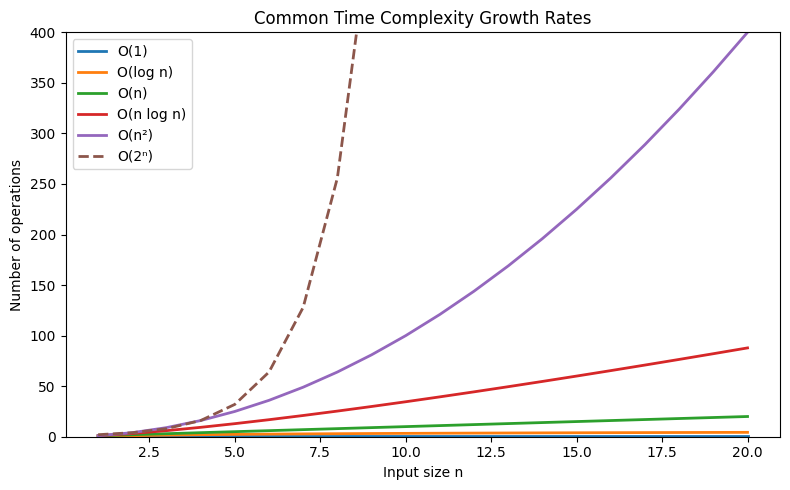

In [13]:
ns = np.arange(1, 21)
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ns, np.ones_like(ns),     label="O(1)",        lw=2)
ax.plot(ns, np.log2(ns),          label="O(log n)",    lw=2)
ax.plot(ns, ns,                   label="O(n)",        lw=2)
ax.plot(ns, ns * np.log2(ns + 1), label="O(n log n)", lw=2)
ax.plot(ns, ns**2,                label="O(n²)",       lw=2)
ax.plot(ns, 2.0**ns,              label="O(2ⁿ)",       lw=2, linestyle='--')

ax.set_ylim(0, 400)
ax.set_xlabel("Input size n")
ax.set_ylabel("Number of operations")
ax.set_title("Common Time Complexity Growth Rates")
ax.legend()
plt.tight_layout()
plt.show()

### 2.8 Worst, Best, and Average Case

Runtime can depend on the **input distribution**:
- **Worst case** O(n): element 1 is at the end → scan everything
- **Best case** Ω(1): element 1 is at the front → find immediately
- **Average case** Θ(n): expected n/2 steps for random permutation

In practice we use **worst-case** as a safety guarantee.

In [14]:
def find_one(nums: list) -> int:
    """Return index of first occurrence of 1.  Worst case O(n), best case O(1)."""
    for i, num in enumerate(nums):
        if num == 1:
            return i
    return -1

# Best case — 1 is first
best_case  = [1, 2, 3, 4, 5]
# Worst case — 1 is last
worst_case = [5, 4, 3, 2, 1]

print("Best  case index:", find_one(best_case))   # 0  (1 step)
print("Worst case index:", find_one(worst_case))  # 4  (n steps)

Best  case index: 0
Worst case index: 4


---
## 3. Space Complexity

Space complexity measures how **memory** requirements scale with n.  
We focus on **working memory** (variables, call stack) and **output**, not the input itself.

**Hierarchy:** O(1) < O(log n) < O(n) < O(n²) < O(2ⁿ)

### 3.1 Constant Space — O(1)

In [15]:
def constant_space(n: int) -> int:
    """O(1) space: only a fixed number of variables regardless of n."""
    a = 0
    b = [0] * 10_000   # fixed size — not proportional to n
    for i in range(n):
        a += i
    return a

### 3.2 Linear Space — O(n)

In [16]:
def linear_space(n: int) -> list:
    """O(n) space: allocate an array of size n."""
    nums = [0] * n    # grows with n
    return nums

# Recursive O(n) space: n stack frames are alive simultaneously
def linear_recur(n: int) -> None:
    """O(n) space from call stack depth."""
    if n == 1:
        return
    linear_recur(n - 1)

### 3.3 Quadratic Space — O(n²)

In [17]:
def quadratic_space(n: int) -> list:
    """O(n²) space: n×n matrix."""
    matrix = [[0] * n for _ in range(n)]
    return matrix

# Show actual memory usage
for n in [10, 100, 1000]:
    mat = quadratic_space(n)
    size_bytes = sys.getsizeof(mat) + sum(sys.getsizeof(row) for row in mat)
    print(f"n={n:4d}: {n}×{n} matrix ≈ {size_bytes:,} bytes")

n=  10: 10×10 matrix ≈ 1,544 bytes
n= 100: 100×100 matrix ≈ 86,520 bytes
n=1000: 1000×1000 matrix ≈ 8,064,856 bytes


### 3.4 Iteration vs Recursion: Space Comparison

Both the loop and the recursive function below have O(n) **time** complexity, but very different **space** complexity.

In [18]:
import tracemalloc

def func() -> int:
    return 0

def loop(n: int) -> None:
    """O(1) space: each call to func() finishes before the next starts."""
    for _ in range(n):
        func()

def recur_space(n: int) -> None:
    """O(n) space: all n frames stay on the call stack at the same time."""
    if n == 1:
        return
    recur_space(n - 1)

n = 200
for name, fn in [("loop  ", loop), ("recur ", recur_space)]:
    tracemalloc.start()
    fn(n)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"{name}: peak memory = {peak:,} bytes")

loop  : peak memory = 88 bytes
recur : peak memory = 0 bytes


### 3.5 Space–Time Tradeoffs

A common engineering decision:
- **Use extra memory to save time** (e.g., caching / memoization)
- **Accept slower runtime to save memory** (e.g., streaming algorithms)

Example: computing Fibonacci with and without caching.

In [19]:
# Slow: O(2^n) time, O(n) space
def fib_slow(n):
    if n <= 1: return n
    return fib_slow(n-1) + fib_slow(n-2)

# Fast with memoization: O(n) time, O(n) space (trading space for time)
from functools import lru_cache

@lru_cache(maxsize=None)
def fib_fast(n):
    if n <= 1: return n
    return fib_fast(n-1) + fib_fast(n-2)

n = 30
t0 = time.perf_counter(); fib_slow(n); t_slow = time.perf_counter() - t0
t0 = time.perf_counter(); fib_fast(n); t_fast = time.perf_counter() - t0

print(f"fib_slow({n}): {t_slow:.4f}s")
print(f"fib_fast({n}): {t_fast:.6f}s  (≈{t_slow/max(t_fast,1e-9):.0f}x faster)")

fib_slow(30): 0.0944s
fib_fast(30): 0.000043s  (≈2213x faster)


---
## 4. Summary

| Concept | Key Idea |
|---|---|
| **Iteration** | Explicit loops; O(1) stack space |
| **Recursion** | Function calls itself; O(depth) stack space |
| **Big-O** | Growth rate of operations as n → ∞; drop constants & lower-order terms |
| **Worst-case** | Safety guarantee; most commonly reported |
| **Space** | Count variables + call stack + output (not the input) |

**Golden rule**: prefer O(n) or O(n log n) algorithms; avoid O(n²) or worse for large n.